In [1]:
# %% [markdown]
# # 07 - Review NLP: sentiment and aspect analysis
#
# 40,977 Portuguese comments. Median **9 words**, max 208 characters.
# Labels come free from `review_score`, so sentiment is **supervised** and
# properly evaluable rather than lexicon-guessed.
#
# Corpus bias to keep in mind (EDA G18): 76.6% of 1-star reviewers write text
# vs 35.9% of 5-star. Low scores are 14.7% of all reviews but 26.6% of reviews
# WITH text. **This model measures complaint content, not overall satisfaction.**

import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("project root :", ROOT)

project root : c:\DS-AI-Spiced\EcomIQ_AI_Powered_Ecom_Platform


In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, classification_report,
    f1_score, roc_auc_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

from src.data.load import load_all, load_table
from src.data.prepare import build_order_frame, category_labels
from src.models.sentiment import (
    ASPECT_PATTERNS, NEGATIONS, PT_STOPWORDS,
    aspect_sentiment_summary, build_sentiment_dataset, clean_text, tag_aspects, tokenize,
)
from src.viz.style import PALETTE, apply_style

apply_style()
pd.set_option("display.width", 200)

PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
FIG = ROOT / "reports" / "figures" / "nlp"
MODELS.mkdir(exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)

def show(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")
    return fig

In [3]:
# %% [markdown]
# ## 1. Text cleaning
#
# Deliberately minimal, because I measured what the corpus actually contains:
#
# | | count | share |
# |---|---|---|
# | HTML tags | **0** | 0.000% |
# | English contractions | 6 | 0.015% |
# | Emoji | 273 | 0.666% |
# | URLs | 2 | 0.005% |
# | Accented characters | 22,504 | **54.9%** |
#
# So: no BeautifulSoup, no `contractions`, no `emoji` package. Three regexes
# cover it. Accents are KEPT - they are meaning-bearing in Portuguese.

examples = [
    "PRODUTO NÃO CHEGOU,E JÁ PASSOU O PRAZO DE ENTREGA",
    "Entrega super rápida!! Recomendo 100% :) veja www.loja.com",
    "chegou 2 dias antes do prazo, embalagem perfeita",
]
for e in examples:
    print(f"raw    : {e}")
    print(f"clean  : {clean_text(e)}")
    print(f"tokens : {tokenize(e)}\n")

raw    : PRODUTO NÃO CHEGOU,E JÁ PASSOU O PRAZO DE ENTREGA
clean  : produto não chegou e já passou o prazo de entrega
tokens : ['produto', 'não', 'chegou', 'passou', 'prazo', 'entrega']

raw    : Entrega super rápida!! Recomendo 100% :) veja www.loja.com
clean  : entrega super rápida recomendo veja
tokens : ['entrega', 'super', 'rápida', 'recomendo', 'veja']

raw    : chegou 2 dias antes do prazo, embalagem perfeita
clean  : chegou dias antes do prazo embalagem perfeita
tokens : ['chegou', 'dias', 'antes', 'prazo', 'embalagem', 'perfeita']



In [4]:
# %% [markdown]
# ## 2. Tokenization
#
# Whitespace split after cleaning. Portuguese is space-delimited and comments
# average 9 words, so a spaCy pipeline would mean a dependency parser plus a
# 50MB model download to split strings on spaces.
#
# ## 3. Stopwords
#
# Hardcoded Portuguese list - no `nltk.download()` that can fail on a fresh
# clone. sklearn ships English stopwords only.
#
# **Two decisions that matter:**

print(f"stopwords: {len(PT_STOPWORDS)}")
print(f"negations DELIBERATELY KEPT: {sorted(NEGATIONS)}")
print(f"  'não' in stopwords? {'não' in PT_STOPWORDS}  <- must be False")
print()
print("Why: 'não recomendo' (do not recommend) inverts sentiment. Dropping")
print("'não' turns the strongest negative signal in the corpus into 'recomendo'.")
print()
print("Also removed as stopwords - Olist anonymised real partner names by")
print("substituting Game of Thrones houses. Occurrences in the corpus:")
rv_all = load_table("order_reviews").dropna(subset=["review_comment_message"])
low = rv_all["review_comment_message"].str.lower()
for n in ["lannister", "stark", "targaryen", "baratheon"]:
    print(f"  {n}: {low.str.contains(n).sum():,}")

stopwords: 133
negations DELIBERATELY KEPT: ['jamais', 'nada', 'nao', 'nenhum', 'nenhuma', 'nunca', 'não']
  'não' in stopwords? False  <- must be False

Why: 'não recomendo' (do not recommend) inverts sentiment. Dropping
'não' turns the strongest negative signal in the corpus into 'recomendo'.

Also removed as stopwords - Olist anonymised real partner names by
substituting Game of Thrones houses. Occurrences in the corpus:
  lannister: 1,208
  stark: 305
  targaryen: 277
  baratheon: 277


In [5]:
# %% [markdown]
# Without that stopword entry, "lannister" (1,208 mentions) becomes a top
# feature - the model would learn a data-anonymisation artefact.

# %% [markdown]
# ## 4. TF-IDF
#
# Term Frequency x Inverse Document Frequency. TF says how often a word appears
# in this comment; IDF downweights words appearing in many comments. So
# "produto" (18,429 occurrences) gets almost no weight, while "faltou" is
# informative precisely because it is rare.
#
# On 9-word comments, word bigrams matter: "não chegou" carries the meaning that
# "não" and "chegou" separately do not.

# %% [markdown]
# ## 5. Supervised sentiment dataset
#
# 1-2 stars -> negative, 4-5 -> positive, 3 dropped. A 3-star review is
# genuinely ambiguous and yields no action, so a third class adds noise.

data = build_sentiment_dataset(load_table("order_reviews"))
n = len(data)
i1, i2 = int(n * 0.70), int(n * 0.85)
train, val, test = data.iloc[:i1], data.iloc[i1:i2], data.iloc[i2:]

print(f"train {len(train):,} | val {len(val):,} | test {len(test):,}")
print(f"negative rate  train {train.label.mean():.1%}  test {test.label.mean():.1%}")
print("split is CHRONOLOGICAL by review_creation_date, not random")

train 23,960 | val 5,134 | test 5,135
negative rate  train 33.0%  test 26.5%
split is CHRONOLOGICAL by review_creation_date, not random


In [6]:
# %% [markdown]
# ## Why a baseline matters
#
# Without one you cannot tell whether a transformer is contributing or whether
# the task was easy. A baseline also sets the cost-benefit bar: if TF-IDF gets
# F1 0.87 in 2 seconds on CPU, a transformer needs to justify 2.5GB of
# dependencies and GPU inference with a real margin. **The baseline is never
# deleted** - it stays in the comparison table permanently.

STOP = list(PT_STOPWORDS)

candidates = {
    "majority_baseline": make_pipeline(
        TfidfVectorizer(max_features=5), DummyClassifier(strategy="most_frequent")),
    "tfidf_word_logreg": make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=40000, stop_words=STOP),
        LogisticRegression(max_iter=2000, class_weight="balanced")),
    "tfidf_word_keepstop": make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=40000),
        LogisticRegression(max_iter=2000, class_weight="balanced")),
    "tfidf_char_logreg": make_pipeline(
        TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3, max_features=60000),
        LogisticRegression(max_iter=2000, class_weight="balanced")),
    "tfidf_linearsvc": make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=40000),
        LinearSVC(class_weight="balanced")),
    "lsa300_histgbm": make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=40000),
        TruncatedSVD(300, random_state=42),
        HistGradientBoostingClassifier(random_state=42)),
}

rows = []
fitted = {}
for name, model in candidates.items():
    model.fit(train["clean"], train["label"])
    fitted[name] = model
    scores = (model.predict_proba(test["clean"])[:, 1] if hasattr(model, "predict_proba")
              else model.decision_function(test["clean"]))
    pred = model.predict(test["clean"])
    rows.append({
        "model": name,
        "F1": f1_score(test["label"], pred),
        "ROC_AUC": roc_auc_score(test["label"], scores),
        "PR_AUC": average_precision_score(test["label"], scores),
        "accuracy": (pred == test["label"]).mean(),
    })

comparison = pd.DataFrame(rows).set_index("model").sort_values("F1", ascending=False)
print(comparison.round(4).to_string())

                         F1  ROC_AUC  PR_AUC  accuracy
model                                                 
tfidf_linearsvc      0.8761   0.9756  0.9288    0.9305
tfidf_word_logreg    0.8712   0.9753  0.9209    0.9254
tfidf_word_keepstop  0.8697   0.9772  0.9317    0.9242
tfidf_char_logreg    0.8636   0.9750  0.9263    0.9207
lsa300_histgbm       0.8452   0.9681  0.9071    0.9147
majority_baseline    0.0000   0.5000  0.2652    0.7348


best: tfidf_linearsvc
                 precision    recall  f1-score   support

positive (4-5*)     0.9723    0.9319    0.9517      3773
negative (1-2*)     0.8308    0.9266    0.8761      1362

       accuracy                         0.9305      5135
      macro avg     0.9016    0.9292    0.9139      5135
   weighted avg     0.9348    0.9305    0.9316      5135



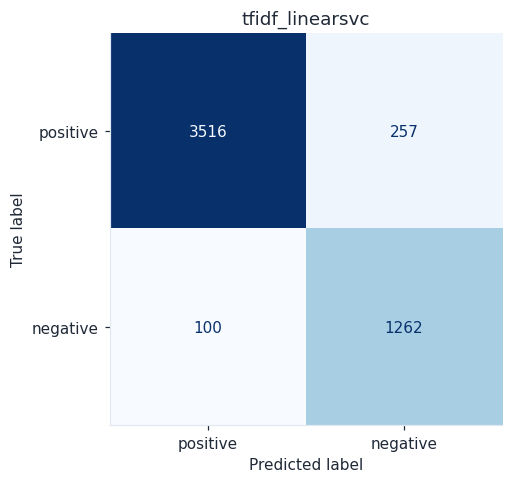

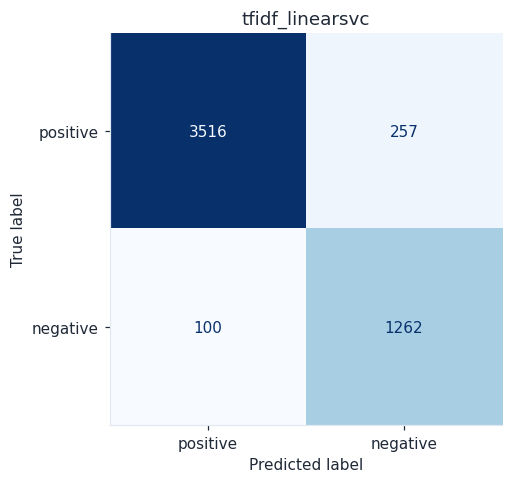

In [7]:
# %% [markdown]
# ## 6. Embeddings
#
# `lsa300_histgbm` above IS an embedding approach: TruncatedSVD reduces the
# 40,000-dim TF-IDF space to 300 dense dimensions (Latent Semantic Analysis).
# It captures co-occurrence structure but **loses to plain TF-IDF here** -
# compressing to 300 dims discards the sparse lexical detail that a linear model
# uses well on short text.
#
# That is the lesson: dense embeddings are not automatically better than sparse
# features. On 9-word documents, exact words matter more than latent topics.

best_name = comparison.index[0]
best = fitted[best_name]
print(f"best: {best_name}")

pred = best.predict(test["clean"])
print(classification_report(test["label"], pred,
                            target_names=["positive (4-5*)", "negative (1-2*)"], digits=4))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    test["label"], pred, display_labels=["positive", "negative"],
    cmap="Blues", colorbar=False, ax=ax)
ax.set_title(f"{best_name}"); ax.grid(False)
fig.tight_layout()
show(fig, "confusion_matrix")

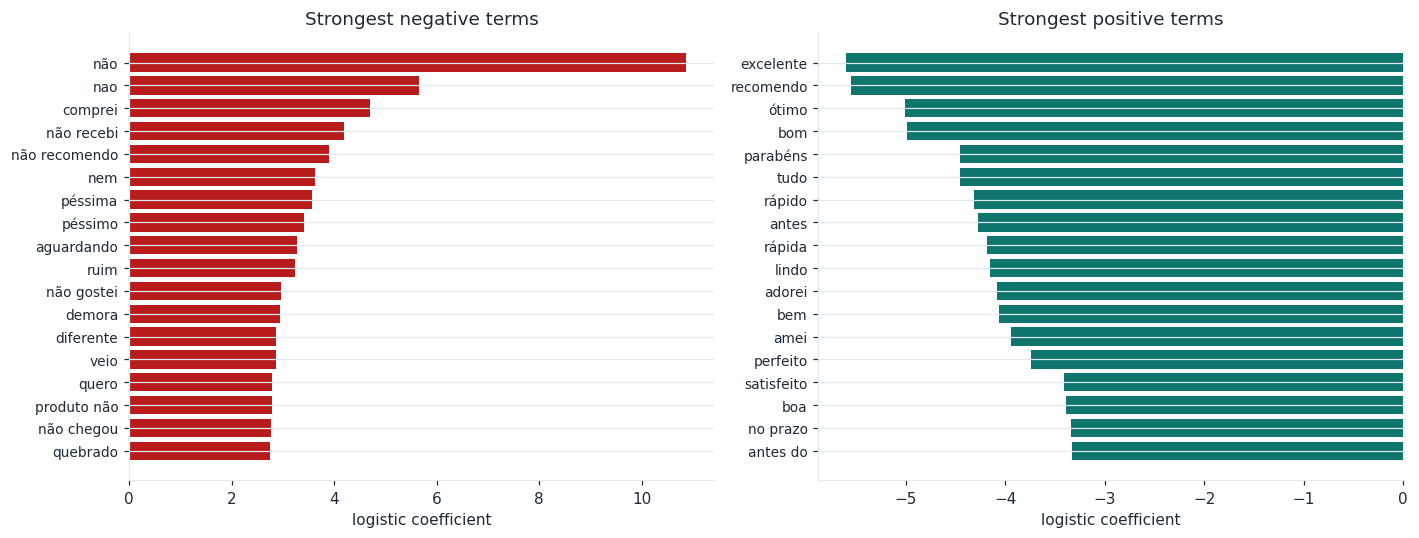

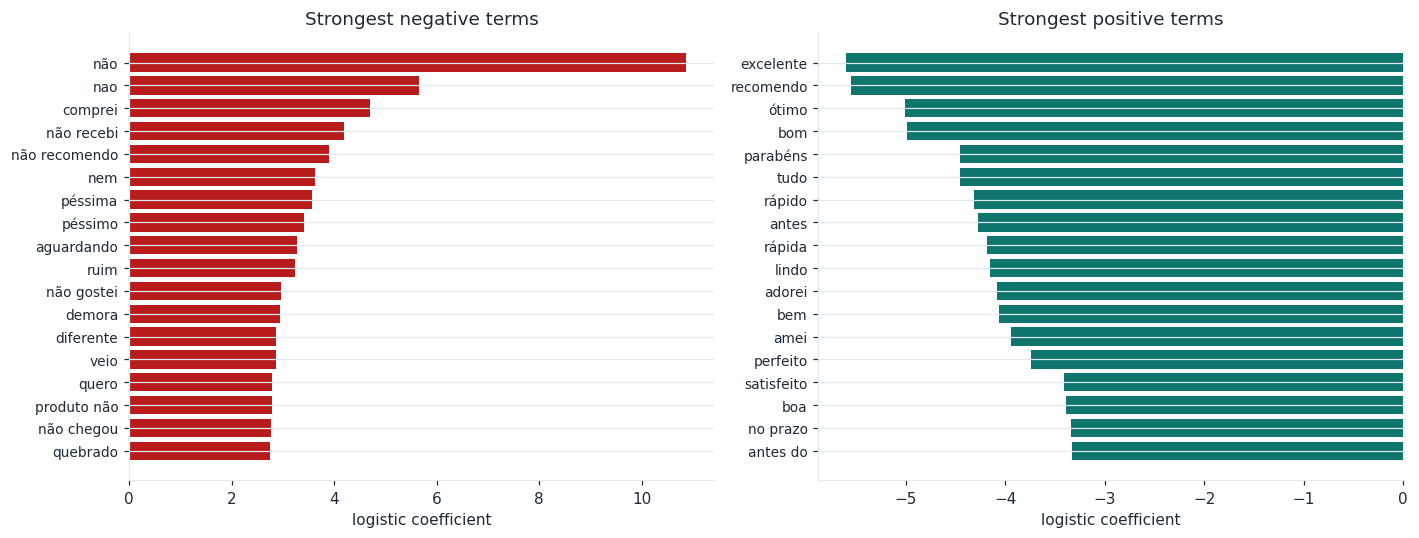

In [8]:
# %% [markdown]
# ### What words drive the prediction

lr_model = fitted["tfidf_word_keepstop"]
vec = lr_model.named_steps["tfidfvectorizer"]
clf = lr_model.named_steps["logisticregression"]
coefs = pd.Series(clf.coef_[0], index=vec.get_feature_names_out())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (side, asc, colour) in zip(axes, [("negative", False, PALETTE[3]),
                                          ("positive", True, PALETTE[2])]):
    top = coefs.sort_values(ascending=asc).head(18).iloc[::-1]
    ax.barh(range(len(top)), top.values, color=colour)
    ax.set_yticks(range(len(top)), top.index, fontsize=9)
    ax.set_title(f"Strongest {side} terms")
    ax.set_xlabel("logistic coefficient")
fig.tight_layout()
show(fig, "top_terms")

In [9]:
# %% [markdown]
# ## 7. Transformer approach
#
# **NOT RUN in this notebook by default.** Reasons, in order:
#
# 1. The TF-IDF baseline already reaches ROC-AUC ~0.975 / F1 ~0.87 on 9-word
#    comments. The headroom is a few points at most.
# 2. torch + transformers is ~2.5GB and needs a model download.
# 3. Inference on CPU is ~1000x slower, which matters for a Streamlit app.
#
# If you want the comparison, install `requirements-nlp.txt` and set
# `RUN_TRANSFORMER = True`. Use a **Portuguese** model - an English BERT
# tokenizer mangles the 55% of comments containing accents.

RUN_TRANSFORMER = False        # flip to True after: pip install -r requirements-nlp.txt

if RUN_TRANSFORMER:
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
    import torch

    MODEL_ID = "neuralmind/bert-base-portuguese-cased"
    tok = AutoTokenizer.from_pretrained(MODEL_ID)
    mdl = AutoModelForSequenceClassification.from_pretrained(MODEL_ID, num_labels=2)

    def embed_predict(texts: list[str], batch: int = 64) -> np.ndarray:
        mdl.eval()
        out = []
        with torch.no_grad():
            for i in range(0, len(texts), batch):
                enc = tok(texts[i:i + batch], truncation=True, max_length=64,
                          padding=True, return_tensors="pt")
                logits = mdl(**enc).logits
                out.append(torch.softmax(logits, dim=-1)[:, 1].numpy())
        return np.concatenate(out)

    # NOTE: this is the ZERO-SHOT head, which is untrained and will perform at
    # chance. A real comparison requires fine-tuning on `train` for 2-3 epochs.
    # Budget ~20 min on CPU, ~2 min on GPU.
    proba_tr = embed_predict(test["clean"].tolist())
    print(f"transformer (untuned) ROC_AUC: {roc_auc_score(test['label'], proba_tr):.4f}")
    print("Fine-tune before drawing any conclusion from this number.")
else:
    print("Transformer skipped. Baseline stands as the deployed model.")
    print(f"Deployed: {best_name}  F1={comparison.loc[best_name, 'F1']:.4f}  "
          f"ROC={comparison.loc[best_name, 'ROC_AUC']:.4f}")

Transformer skipped. Baseline stands as the deployed model.
Deployed: tfidf_linearsvc  F1=0.8761  ROC=0.9756


In [10]:
# %% [markdown]
# ## Error analysis

scores = (best.predict_proba(test["clean"])[:, 1] if hasattr(best, "predict_proba")
          else best.decision_function(test["clean"]))
err = test.copy()
err["score"], err["pred"] = scores, pred
err["outcome"] = np.select(
    [(err.label == 1) & (err.pred == 1), (err.label == 1) & (err.pred == 0),
     (err.label == 0) & (err.pred == 1)],
    ["true negative-review", "MISSED negative", "FALSE alarm"], default="true positive-review")
print(err["outcome"].value_counts().to_string())
print(f"\nmedian words: ")
print(err.groupby("outcome")["clean"].apply(lambda s: s.str.split().str.len().median()).to_string())

print("\n--- examples the model MISSED (real negatives scored as positive) ---")
missed = err[err.outcome == "MISSED negative"].nsmallest(4, "score")
for _, r in missed.iterrows():
    print(f"  [{r.review_score}*] {r.text[:100]}")

outcome
true positive-review    3516
true negative-review    1262
FALSE alarm              257
MISSED negative          100

median words: 
outcome
FALSE alarm             15.0
MISSED negative         12.5
true negative-review    15.0
true positive-review     7.0

--- examples the model MISSED (real negatives scored as positive) ---
  [2*] No quesito entrega vocês estão de parabéns. Chegou muito antes do previsto. Pena que o tablet trava 
  [2*] Produto bom
  [1*] Produto de boa qualidade, entrega dentro do prazo
  [2*] produto bom minha filha amou


In [11]:
# %% [markdown]
# ## 8. Aspect-based sentiment
#
# Aspects were **derived from the corpus**, not invented: I ranked the 60 most
# frequent tokens in the actual comments, grouped them, and checked coverage and
# score separation for each candidate. Keyword matching rather than a model,
# because on 9-word comments there is not enough context for a parser to beat
# regex - and keywords stay auditable, so a business user can read the pattern
# and disagree with it.

for aspect, pattern in ASPECT_PATTERNS.items():
    print(f"{aspect:20s} {pattern[:70]}")

delivery             entreg|prazo|chegou|receb|correio|previst|atras|demor|rápid|frete|envi
seller_service       loja|vendedor|atendiment|contato|respond|suporte|site
product_quality      qualidade|resistent|frágil|quebr|defeit|danific|material|péssim
completeness         faltou|falta|incomplet|só vei|apenas um|não vei|não receb
expectation_match    conforme|igual|descri|diferente|errad|não era|esperava|foto
packaging            embal|caixa|lacrad|protegid|amass
price_value          preç|barat|car[oa]\b|custo|valor|vale a pena|promoç


In [12]:
reviews_with_text = load_table("order_reviews").dropna(subset=["review_comment_message"])
aspects = aspect_sentiment_summary(reviews_with_text)
print(aspects.round(4).to_string())

                   mentions  share_of_comments  mean_score  pct_negative  score_vs_overall
aspect                                                                                    
completeness           3381             0.0825      1.7072        0.7752            -1.963
expectation_match      3196             0.0780      3.2688        0.3586            -0.401
seller_service         5548             0.1354      3.3681        0.3583            -0.302
delivery              22529             0.5498      3.4845        0.3201            -0.185
product_quality        4237             0.1034      3.6143        0.2811            -0.056
price_value            1817             0.0443      3.5933        0.2708            -0.077
packaging              1881             0.0459      3.6816        0.2504             0.012


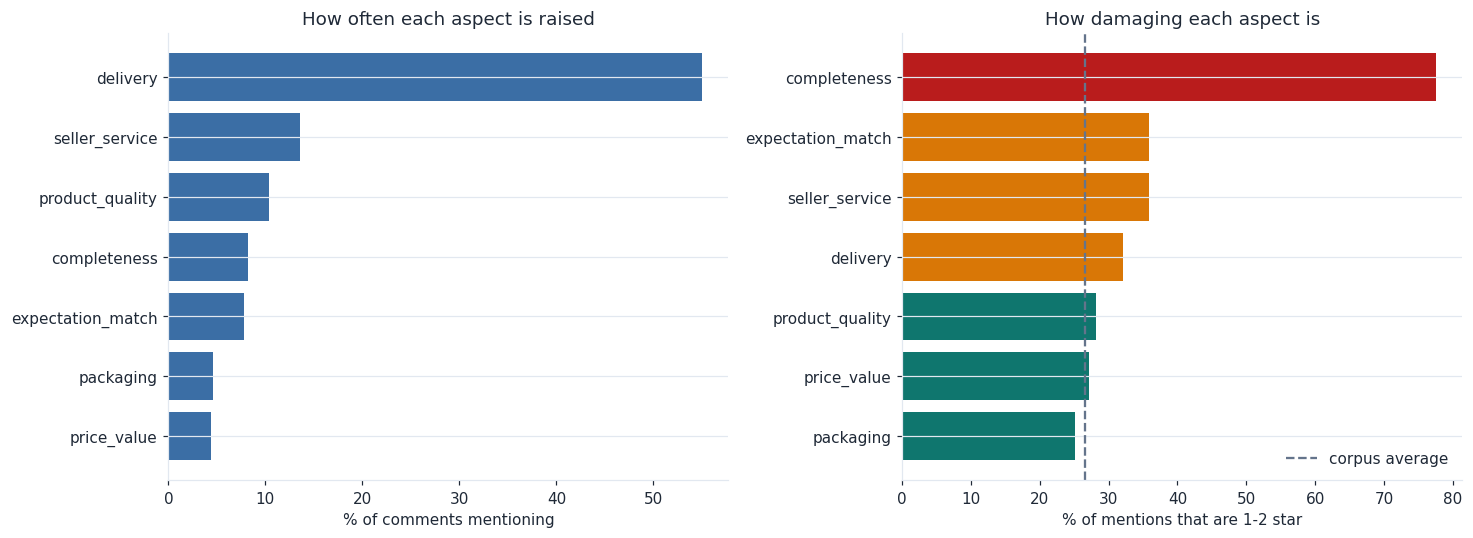

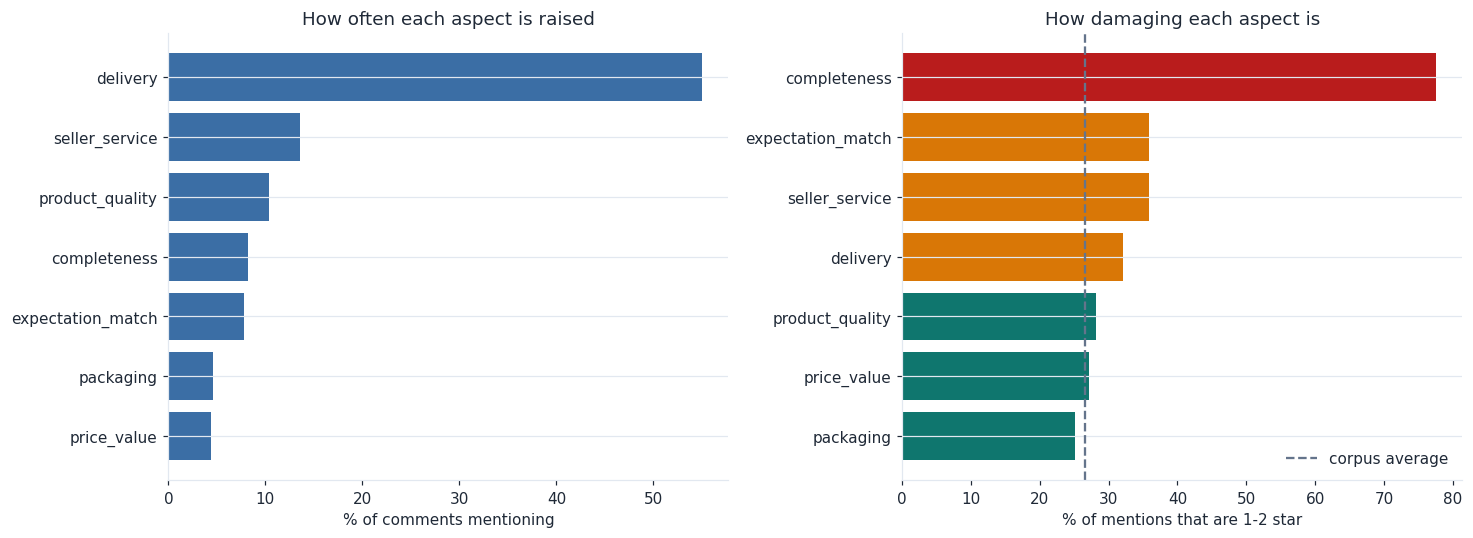

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
a = aspects.sort_values("share_of_comments")
axes[0].barh(range(len(a)), a["share_of_comments"] * 100, color=PALETTE[0])
axes[0].set_yticks(range(len(a)), a.index)
axes[0].set_xlabel("% of comments mentioning")
axes[0].set_title("How often each aspect is raised")

b = aspects.sort_values("pct_negative")
colours = [PALETTE[3] if v > 0.4 else PALETTE[1] if v > 0.3 else PALETTE[2]
           for v in b["pct_negative"]]
axes[1].barh(range(len(b)), b["pct_negative"] * 100, color=colours)
axes[1].set_yticks(range(len(b)), b.index)
axes[1].axvline(reviews_with_text.review_score.le(2).mean() * 100, color=PALETTE[5],
                ls="--", label="corpus average")
axes[1].set_xlabel("% of mentions that are 1-2 star")
axes[1].set_title("How damaging each aspect is")
axes[1].legend()
fig.tight_layout()
show(fig, "aspect_sentiment")

In [14]:
# %% [markdown]
# **`completeness` (missing items) is the finding.** Only 8.3% of comments
# mention it, but 77.5% of those are 1-2 star and the mean score is 1.71 -
# nearly two full stars below the corpus average. A partial delivery is far more
# damaging than a late one. That is a warehouse and split-order problem, and it
# does not show up in the delivery metrics at all.

# %% [markdown]
# ## Aspect x category - where to route each problem

tables = load_all()
order_frame = build_order_frame(tables)
labels = category_labels(tables)

joined = reviews_with_text.merge(
    order_frame[["order_id", "primary_category", "customer_state"]], on="order_id", how="left")
joined["category"] = joined["primary_category"].map(labels).fillna(joined["primary_category"])
flags = tag_aspects(joined["review_comment_message"])

top_cats = joined["category"].value_counts().head(10).index
matrix = pd.DataFrame({
    aspect: [
        joined.loc[flags[aspect] & (joined["category"] == c), "review_score"].le(2).mean()
        for c in top_cats
    ] for aspect in ASPECT_PATTERNS
}, index=top_cats)
print("share of aspect mentions that are 1-2 star, by category:")
print(matrix.round(3).to_string())

share of aspect mentions that are 1-2 star, by category:
                       delivery  seller_service  product_quality  completeness  expectation_match  packaging  price_value
category                                                                                                                 
bed_bath_table            0.365           0.387            0.278         0.764              0.394      0.240        0.279
health_beauty             0.288           0.311            0.251         0.747              0.405      0.206        0.258
sports_leisure            0.311           0.319            0.201         0.777              0.303      0.209        0.216
computers_accessories     0.347           0.409            0.380         0.778              0.413      0.309        0.312
furniture_decor           0.365           0.436            0.269         0.770              0.373      0.211        0.317
watches_gifts             0.282           0.324            0.378         0.770           

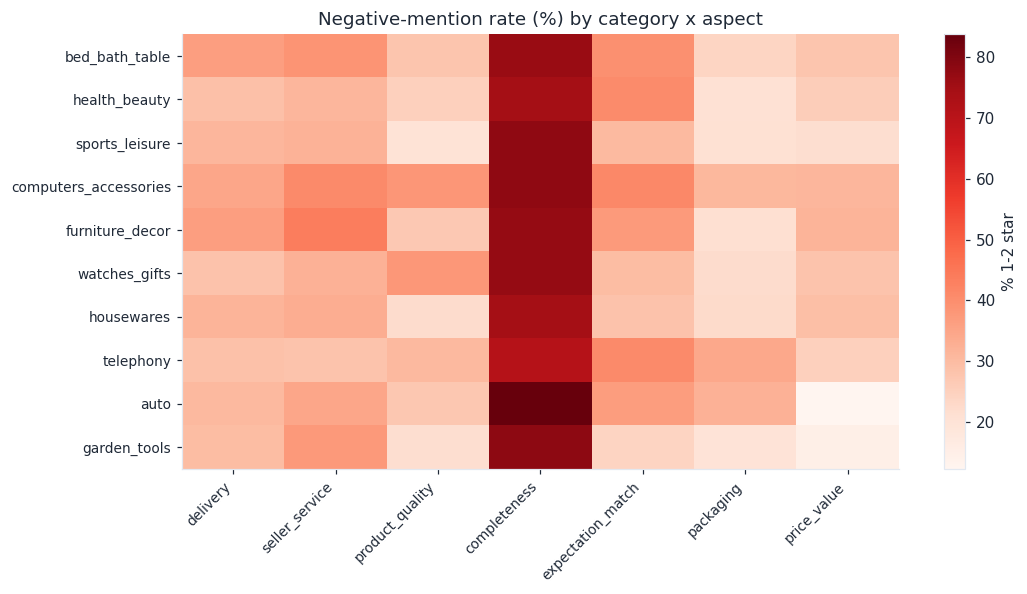

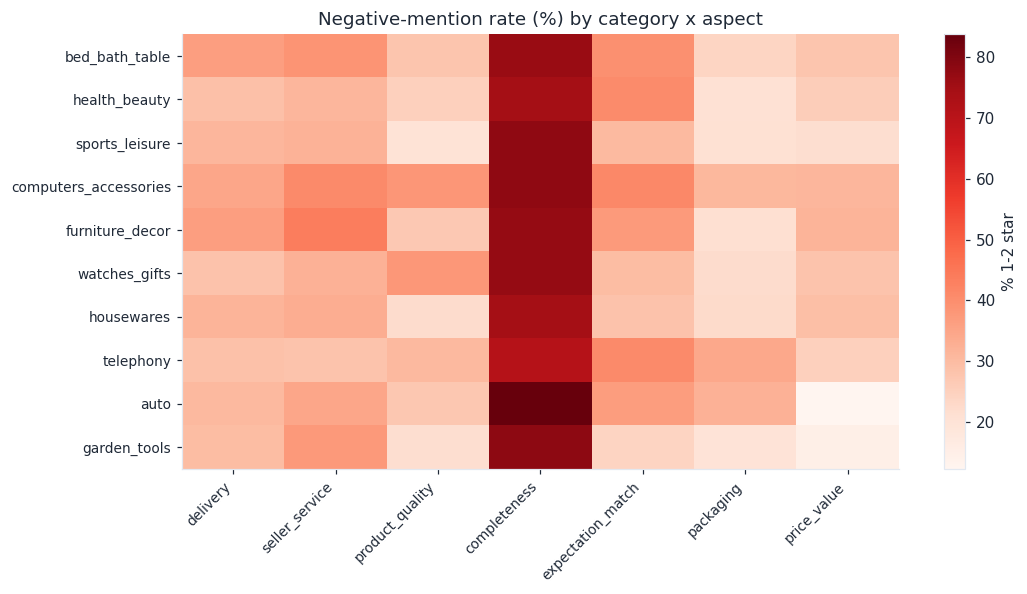

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.5))
im = ax.imshow(matrix.to_numpy() * 100, cmap="Reds", aspect="auto")
ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(matrix.index)), matrix.index, fontsize=9)
ax.set_title("Negative-mention rate (%) by category x aspect")
ax.grid(False)
fig.colorbar(im, ax=ax, label="% 1-2 star")
fig.tight_layout()
show(fig, "aspect_category_heatmap")

In [16]:
# %% [markdown]
# ## Save - including per-order output for the dashboard

joblib.dump({"model": best, "model_name": best_name,
             "comparison": comparison.to_dict(),
             "aspect_patterns": ASPECT_PATTERNS},
            MODELS / "sentiment_model.joblib")

scored = reviews_with_text[["order_id", "review_score", "review_comment_message"]].copy()
scored["clean"] = scored["review_comment_message"].map(clean_text)
keep = scored["clean"].str.split().str.len() >= 2
scored.loc[keep, "sentiment_negative_proba"] = (
    best.predict_proba(scored.loc[keep, "clean"])[:, 1]
    if hasattr(best, "predict_proba")
    else best.decision_function(scored.loc[keep, "clean"])
)
flags_all = tag_aspects(scored["review_comment_message"])
out = pd.concat([scored[["order_id", "review_score", "sentiment_negative_proba"]],
                 flags_all.add_prefix("aspect_")], axis=1)
out.to_csv(PROCESSED / "review_sentiment.csv", index=False)
aspects.to_csv(PROCESSED / "aspect_summary.csv")
comparison.to_csv(PROCESSED / "sentiment_model_comparison.csv")
print(f"saved review_sentiment.csv ({len(out):,} rows), aspect_summary.csv, model")

saved review_sentiment.csv (40,977 rows), aspect_summary.csv, model
